# Demo Build CNN

## 1. Buil the CNN

In [1]:
# Importing the Keras libraries and other packages
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from datetime import datetime
import pandas as pd
from tensorflow.keras.utils import plot_model
from IPython.display import Image
from tensorflow.keras.models import load_model

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
print(tf.__version__)
print(keras.__version__)

2.8.2
2.8.0


Ví dụ: Nhận biết một hình ảnh là "dog" hay "cat"

In [4]:
classifier = Sequential()

In [5]:
# Step 1 - Convolution
classifier.add(Conv2D(filters=32, kernel_size=3,
input_shape=(64, 64, 3), activation='relu'))

# Step 2 - Pooling
classifier.add(MaxPooling2D(pool_size=(2, 2)))

In [6]:
# Adding a second convolutional layer
classifier.add(Conv2D(filters=32, kernel_size=3,
                      activation='relu'))
classifier.add(MaxPooling2D(pool_size=(2, 2)))

Chú ý: Number of filters là một tham số có thể được điều chỉnh, cao hơn hoặc thấp hơn tùy kích thước của dataset/tính chất của model.

In [7]:
# Step 3 - Flattening
classifier.add(Flatten())

# Step 4 - Full connection
classifier.add(Dense(units=128, activation='relu'))
classifier.add(Dense(units=1, activation='sigmoid'))

In [8]:
# Compiling the CNN
classifier.compile(optimizer='adam',
                   loss='binary_crossentropy', metrics=['accuracy'])

Chú ý: Có thể cải tiến bằng cách dùng thêm Dropout sau mỗi add(MaxPooling2D()) hoặc add(Dense()) của các layer khác output layer.

## 2. Read and pre-process images

In [9]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

- rescale: Yếu tố thay đổi kích thước. Mặc định là None (hoặc 0, không áp dụng thay đổi kích thước), nếu khác None/0, sẽ nhân dữ liệu với các giá trị được cung cấp (sau khi áp dụng tất cả các biến đổi khác).
- shear_range: Góc cắt theo hướng ngược chiều kim đồng hồ theo độ.
- zoom_range: Range for random zoom (phạm vi thu phóng ngẫu nhiên).

In [10]:
training_set = train_datagen.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/Projects/CNN_Demo/dataset/training_set',
                                  target_size=(64, 64),
                                  batch_size=32,
                                  class_mode='binary')

test_set = test_datagen.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/Projects/CNN_Demo/dataset/test_set',
                                  target_size=(64, 64),
                                  batch_size=32,
                                  class_mode='binary')

Found 8011 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


## 3. Fit the CNN to the images

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [EarlyStopping(monitor='val_loss',
                           patience=5),
             ModelCheckpoint('model_checkpoint_18052022.h5',
                             save_best_only=True)]

In [12]:
history = classifier.fit(training_set,
                         epochs=100,
                         validation_data=test_set,
                         callbacks=callbacks)

Epoch 1/100
251/251 [==============================] - 1416s 6s/step - loss: 0.6833 - accuracy: 0.5599 - val_loss: 0.6577 - val_accuracy: 0.5965
Epoch 2/100
251/251 [==============================] - 85s 340ms/step - loss: 0.6178 - accuracy: 0.6607 - val_loss: 0.7529 - val_accuracy: 0.5740
Epoch 3/100
251/251 [==============================] - 85s 337ms/step - loss: 0.5780 - accuracy: 0.6973 - val_loss: 0.5567 - val_accuracy: 0.7280
Epoch 4/100
251/251 [==============================] - 86s 342ms/step - loss: 0.5477 - accuracy: 0.7201 - val_loss: 0.5097 - val_accuracy: 0.7605
Epoch 5/100
251/251 [==============================] - 84s 333ms/step - loss: 0.5268 - accuracy: 0.7350 - val_loss: 0.5246 - val_accuracy: 0.7345
Epoch 6/100
251/251 [==============================] - 84s 333ms/step - loss: 0.5063 - accuracy: 0.7520 - val_loss: 0.4876 - val_accuracy: 0.7655
Epoch 7/100
251/251 [==============================] - 85s 339ms/step - loss: 0.4961 - accuracy: 0.7606 - val_loss: 0.4733 - 

In [ ]:
# from datetime import datetime
# print(datetime.datetime.now())

## 4. Plot the history

In [13]:
import pandas as pd
history_frame = pd.DataFrame(history.history)

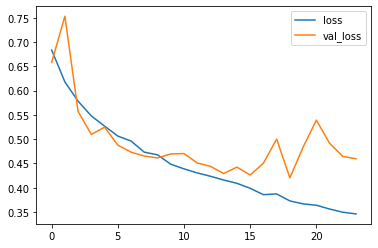

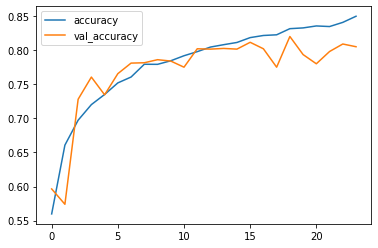

In [14]:
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot()

## 5. Visualize model

In [15]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image

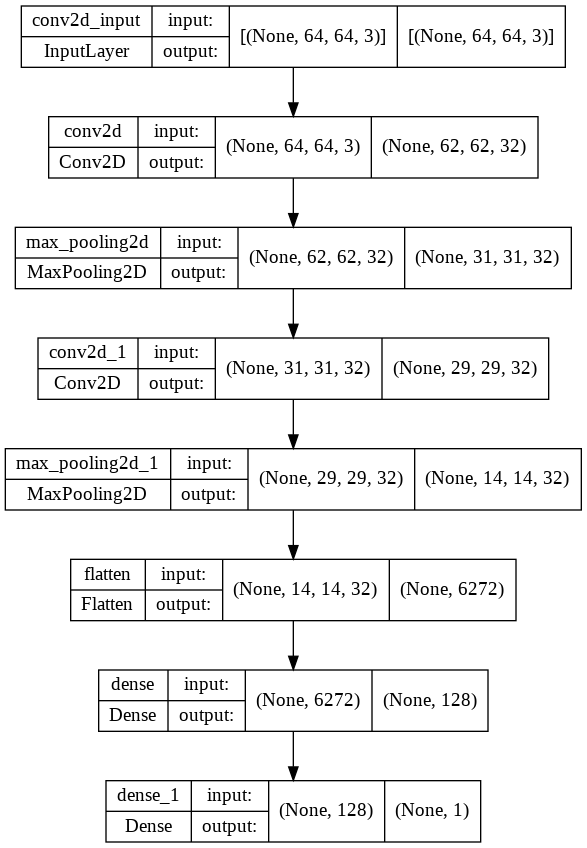

In [16]:
plot_model(classifier, to_file='CNN_model_20082021.png', show_shapes=True)
Image(filename='CNN_model_20082021.png')

## 6. Save model

In [17]:
from tensorflow.keras.models import load_model
# Create a HDF5 file 'my_model_CNN.h5'
classifier.save('/content/drive/MyDrive/Colab Notebooks/Projects/CNN_Demo/my_model_CNN_25052022.h5')